### This is an implementation of the XOR classifier using alternating projections

In [47]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import jax.numpy as jnp
import jax.random as random
import tools.optimize as optimize
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import jax
rand_key = random.key(123)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
@jax.jit
def reluActivationVectorized(x, W, z):
    """
    Vectorized ReLU activation projection.
    x is the pre-activation input, W is the identity matrix, z is the target post-activation.
    """
    H = W @ x

    # Solution 1: project onto inactive branch (x <= 0, output = 0)
    x_1 = jnp.clip(H, a_max=0)
    dist_1 = (H - x_1)**2 + z**2

    # Solution 2: project onto active branch (x > 0, output = x)
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    dist_2 = (H - x_2)**2 + (z - x_2)**2

    # Select solution minimizing distance
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, 0.0, x_2)

    return new_H, W, new_z

@jax.jit
def leakyReluActivationVectorized(x, W, z, slope=0.1):
    """
    Vectorized Leaky ReLU activation projection.
    x is the pre-activation input, W is the identity matrix, z is the target post-activation.
    """
    H = W @ x

    # Solution 1: project onto inactive branch (x <= 0, output = slope * x)
    x_1 = jnp.clip((H + slope * z) / (1.0 + slope * slope), a_max=0)
    y_1 = slope * x_1
    dist_1 = (H - x_1)**2 + (z - y_1)**2

    # Solution 2: project onto active branch (x > 0, output = x)
    x_2 = jnp.clip((H + z) / 2.0, a_min=0)
    y_2 = x_2
    dist_2 = (H - x_2)**2 + (z - y_2)**2

    # Select solution minimizing distance
    new_H = jnp.where(dist_1 < dist_2, x_1, x_2)
    new_z = jnp.where(dist_1 < dist_2, y_1, y_2)

    return new_H, W, new_z

In [ ]:
### setup problem
NUM_INPUT_BITS = 2
HIDDEN_WIDTH = 200

def make_xor_dataset(num_input_bits):
    num_samples = 2 ** num_input_bits
    indices = jnp.arange(num_samples, dtype=jnp.int32)
    bit_positions = jnp.arange(num_input_bits, dtype=jnp.int32)

    # Shape: (num_input_bits, num_samples)
    X = ((indices[:, None] >> bit_positions) & 1).T
    y = jnp.mod(jnp.sum(X, axis=0), 2)
    return X, y

xor_X, xor_y = make_xor_dataset(NUM_INPUT_BITS)
input_dim = xor_X.shape[0]

delta = 1.0

# Experiment Parameters
num_trials = 5
BACKWARDS_PASSES = 1000

def forward_pass(W0, W1, x_in):
    x_hidden    = W0 @ x_in
    h_hidden    = jnp.where(x_hidden > 0, x_hidden, 0.1 * x_hidden)  # Leaky ReLU
    x_out       = W1 @ h_hidden

    # Calculate error
    y_target = jnp.atleast_2d(xor_y)
    err1 = jnp.where(y_target == 1, jnp.where(x_out < delta, (x_out - delta)**2, 0), 0)
    err0 = jnp.where(y_target == 0, jnp.where(x_out > 0, x_out**2, 0), 0)
    batchError = err1 + err0
    return batchError, x_hidden, h_hidden, x_out


## Cyclic projections


In [ ]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))

    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in        = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        bf = x_out
        h_hidden, W1, x_out = projections.matmul_proj(h_hidden, W1, x_out)
        
        # Activation layer step projection
        x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)

        # Input layer matmul projection
        x_in, W0, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
        
        # do a logging forward pass to get the current error after projections
        batchError, _, _, _ = forward_pass(W0, W1, xor_X)
            
        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 3.06e-11


      Trial  Iteration         Error
0         0          0  3.412309e+00
1         0          1  2.466705e+00
2         0          2  1.822712e+00
3         0          3  1.380615e+00
4         0          4  1.070270e+00
...     ...        ...           ...
5000      4        996  3.058205e-11
5001      4        997  3.764524e-11
5002      4        998  3.517716e-11
5003      4        999  3.517716e-11
5004      4       1000  3.058205e-11

[5005 rows x 3 columns]


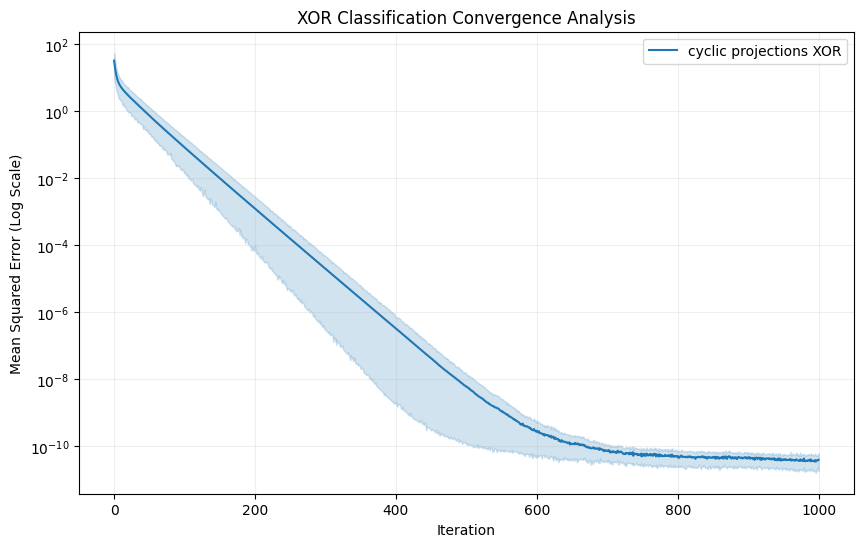

In [63]:
### Visualize Results
import numpy as np
df_pure = pd.DataFrame(results.copy())
print(df_pure)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pure, x="Iteration", y="Error", label='cyclic projections XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## nonlinear relaxed projection (weights)


In [52]:
import optax

optim_W0 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_W1 = optax.sgd(learning_rate=1.0, momentum=0.9)


In [ ]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))
    optim_state_W0 = optim_W0.init(W0)

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))
    optim_state_W1 = optim_W1.init(W1)
    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden, w1_proj, x_out = projections.matmul_proj(h_hidden, W1, x_out)
        pseudo_grads_W1 = W1 - w1_proj
        updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
        W1 = optax.apply_updates(W1, updates_W1)

        # Activation layer step projection
        x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)

        # Input layer matmul projection
        x_in, w0_proj, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
        pseudo_grads_W0 = W0 - w0_proj
        updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
        W0 = optax.apply_updates(W0, updates_W0)

        # Do a logging forward pass to get the current error after projections
        batchError, _, _, _ = forward_pass(W0, W1, xor_X)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 0.00e+00


      Trial  Iteration     Error
0         0          0  3.412309
1         0          1  2.466705
2         0          2  1.212369
3         0          3  0.358934
4         0          4  0.043203
...     ...        ...       ...
5000      4        996  0.000000
5001      4        997  0.000000
5002      4        998  0.000000
5003      4        999  0.000000
5004      4       1000  0.000000

[5005 rows x 3 columns]


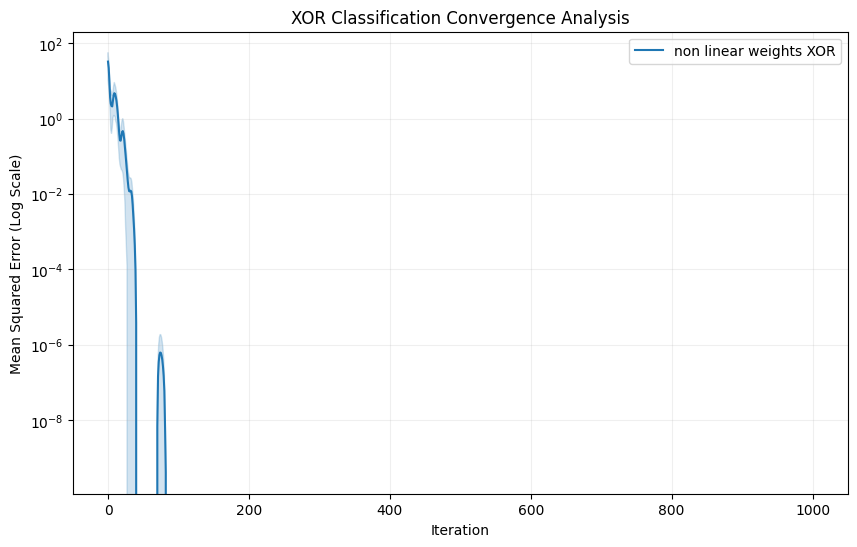

In [65]:
### Visualize Results
import numpy as np
df_non_linear_weights = pd.DataFrame(results.copy())
print(df_non_linear_weights)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_linear_weights, x="Iteration", y="Error", label='non linear weights XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## nonlinear relaxed projection (full)

In [66]:
import optax

optim_W0 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_W1 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_h_hidden = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_x_hidden = optax.sgd(learning_rate=1.0, momentum=0.9)



In [ ]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))
    optim_state_W0 = optim_W0.init(W0)

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))
    optim_state_W1 = optim_W1.init(W1)
    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    optim_state_x_hidden = optim_x_hidden.init(x_hidden)
    optim_state_h_hidden = optim_h_hidden.init(h_hidden)

    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden_proj, w1_proj, x_out = projections.matmul_proj(h_hidden, W1, x_out)
        
        pseudo_grads_W1 = W1 - w1_proj
        updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
        W1 = optax.apply_updates(W1, updates_W1)
        
        pseudo_grads_h_hidden = h_hidden - h_hidden_proj
        updates_h_hidden, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h_hidden, optim_state_h_hidden, h_hidden)
        h_hidden = optax.apply_updates(h_hidden, updates_h_hidden)

        # Activation layer step projection
        x_hidden_proj, _, h_hidden_proj = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)
        
        pseudo_grads_h_hidden = h_hidden - h_hidden_proj
        updates_h_hidden, optim_state_h_hidden = optim_h_hidden.update(pseudo_grads_h_hidden, optim_state_h_hidden, h_hidden)
        h_hidden = optax.apply_updates(h_hidden, updates_h_hidden)

        pseudo_grads_x_hidden = x_hidden - x_hidden_proj
        updates_x_hidden, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x_hidden, optim_state_x_hidden, x_hidden)
        x_hidden = optax.apply_updates(x_hidden, updates_x_hidden)

        # Input layer matmul projection
        x_in, w0_proj, x_hidden_proj = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
        
        pseudo_grads_W0 = W0 - w0_proj
        updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
        W0 = optax.apply_updates(W0, updates_W0)

        pseudo_grads_x_hidden = x_hidden - x_hidden_proj
        updates_x_hidden, optim_state_x_hidden = optim_x_hidden.update(pseudo_grads_x_hidden, optim_state_x_hidden, x_hidden)
        x_hidden = optax.apply_updates(x_hidden, updates_x_hidden)

        # Do a logging forward pass to get the current error after projections
        batchError, _, _, _ = forward_pass(W0, W1, xor_X)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 0.00e+00


      Trial  Iteration     Error
0         0          0  3.412309
1         0          1  2.466705
2         0          2  1.019358
3         0          3  0.099365
4         0          4  0.000000
...     ...        ...       ...
5000      4        996  0.000000
5001      4        997  0.000000
5002      4        998  0.000000
5003      4        999  0.000000
5004      4       1000  0.000000

[5005 rows x 3 columns]


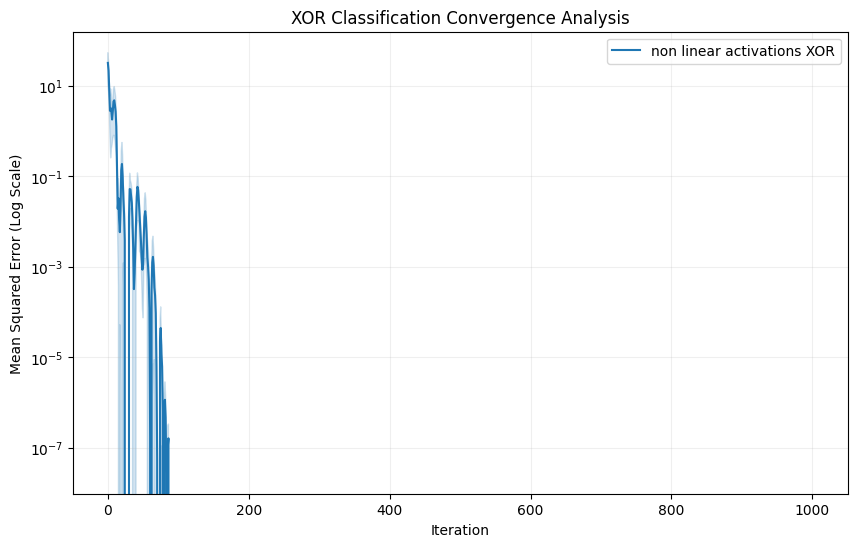

In [68]:
### Visualize Results
import numpy as np
df_non_linear_activations = pd.DataFrame(results.copy())
print(df_non_linear_activations)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_linear_activations, x="Iteration", y="Error", label='non linear activations XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## non linear relaxation (weights) with forward


In [ ]:
import optax

optim_W0 = optax.sgd(learning_rate=1.0, momentum=0.9)
optim_W1 = optax.sgd(learning_rate=1.0, momentum=0.9)


In [ ]:
### Run Alternating Projections Experiment
results = []
key = rand_key
for trial in range(num_trials):
    # Initialize weights
    key, k1, k2 = random.split(key, 3)
    W0 = random.normal(k1, (HIDDEN_WIDTH, input_dim))
    optim_state_W0 = optim_W0.init(W0)

    W1 = random.normal(k2, (1, HIDDEN_WIDTH))
    optim_state_W1 = optim_W1.init(W1)
    
    # ------------------------------------------------------------------
    # FORWARD PASS 
    # ------------------------------------------------------------------
    x_in = xor_X
    y_target = jnp.atleast_2d(xor_y)
    batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)
    
    # Log progress
    current_error = jnp.mean(batchError)
    results.append({
        "Trial":     trial,
        "Iteration": 0,
        "Error":     float(current_error),
    })
    
    # ------------------------------------------------------------------
    # BACKWARD PASS
    # ------------------------------------------------------------------
    for i in range(BACKWARDS_PASSES):  # Number of inner projection steps
        # Output layer constraint projection
        x_out, _, _ = projections.classifierOutputVector(x_out, jnp.eye(1), y_target)

        # Hidden layer matmul projection
        h_hidden, w1_proj, x_out = projections.matmul_proj(h_hidden, W1, x_out)
        pseudo_grads_W1 = W1 - w1_proj
        updates_W1, optim_state_W1 = optim_W1.update(pseudo_grads_W1, optim_state_W1, W1)
        W1 = optax.apply_updates(W1, updates_W1)

        # Activation layer step projection
        x_hidden, _, h_hidden = leakyReluActivationVectorized(x_hidden, jnp.eye(HIDDEN_WIDTH), h_hidden)

        # Input layer matmul projection
        x_in, w0_proj, x_hidden = projections.matmul_proj_fixed_X(x_in, W0, x_hidden)
        pseudo_grads_W0 = W0 - w0_proj
        updates_W0, optim_state_W0 = optim_W0.update(pseudo_grads_W0, optim_state_W0, W0)
        W0 = optax.apply_updates(W0, updates_W0)

        # Do a logging forward pass to get the current error after projections
        batchError, x_hidden, h_hidden, x_out = forward_pass(W0, W1, xor_X)

        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial":     trial,
            "Iteration": i + 1,
            "Error":     float(current_error),
        })
print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Final Error (Last Trial): 0.00e+00


      Trial  Iteration     Error
0         0          0  3.412309
1         0          1  2.466705
2         0          2  1.180148
3         0          3  0.237987
4         0          4  0.166997
...     ...        ...       ...
5000      4        996  0.000000
5001      4        997  0.000000
5002      4        998  0.000000
5003      4        999  0.000000
5004      4       1000  0.000000

[5005 rows x 3 columns]


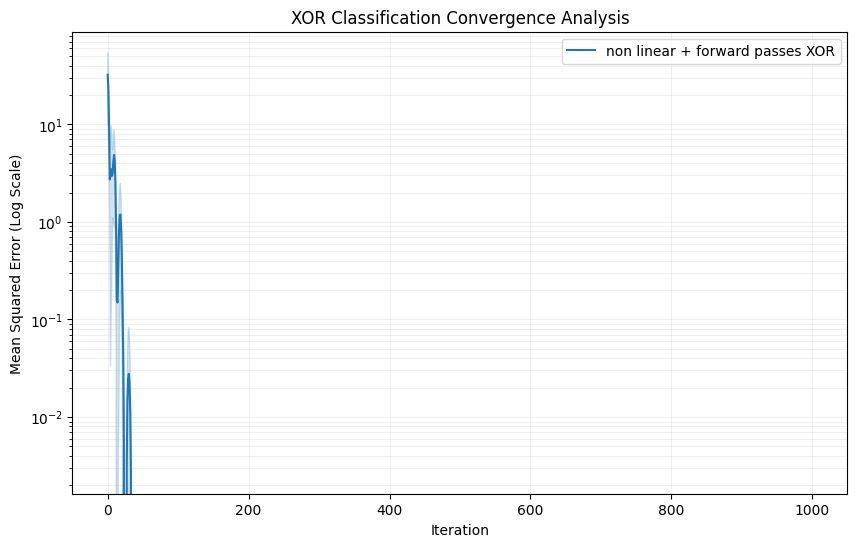

In [83]:
### Visualize Results
import numpy as np
df_non_linear_with_forward = pd.DataFrame(results.copy())
print(df_non_linear_with_forward)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_linear_with_forward, x="Iteration", y="Error", label='non linear + forward passes XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

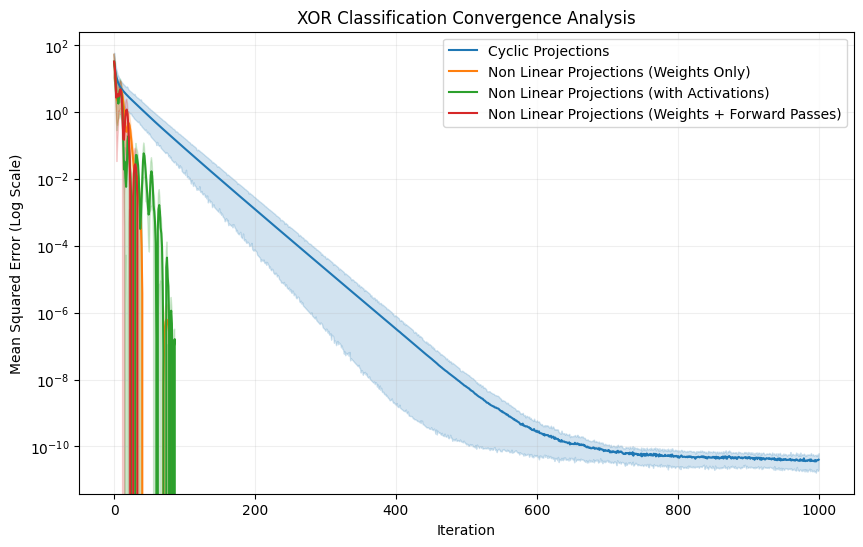

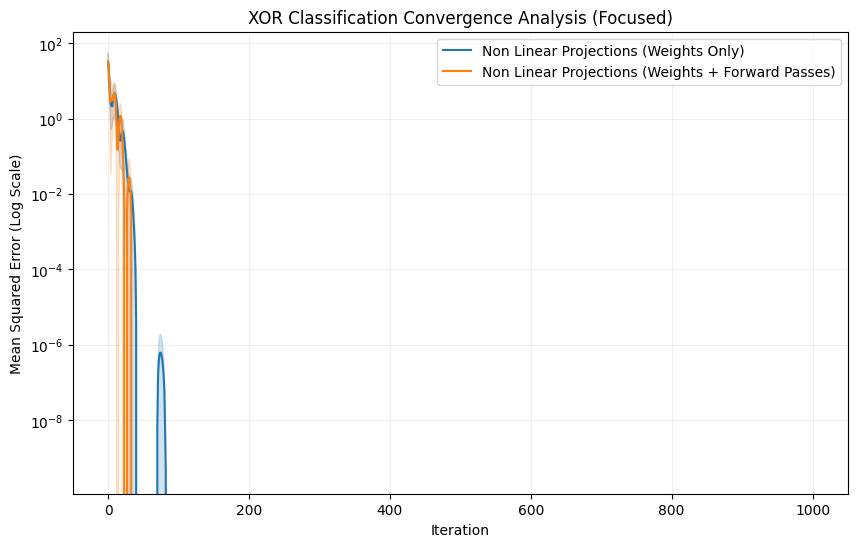

In [85]:
df_pure['method'] = 'Cyclic Projections'
df_non_linear_weights['method'] = 'Non Linear Projections (Weights Only)'
df_non_linear_activations['method'] = 'Non Linear Projections (with Activations)'
df_non_linear_with_forward['method'] = 'Non Linear Projections (Weights + Forward Passes)'

# Merge vertically
df_full = pd.concat([df_pure, df_non_linear_weights, df_non_linear_activations, df_non_linear_with_forward], ignore_index=True)

## plot 
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_full, x="Iteration", y="Error", hue="method")
plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## plot only the non linear weights and non linear with forward passes
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_full[df_full['method'].isin(['Non Linear Projections (Weights Only)', 'Non Linear Projections (Weights + Forward Passes)'])], x="Iteration",
                y="Error", hue="method")
plt.yscale('log')
plt.title("XOR Classification Convergence Analysis (Focused)")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()